## Introduction : 

In this project, I analyzed customer shopping behavior using transaction data from different shopping malls.
The objective was to identify customer spending patterns, understand product preferences, and uncover factors that drive revenue.
The insights from this analysis can help businesses make better decisions related to marketing, inventory planning, and customer engagement.

## Imported Libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [44]:
df = pd.read_csv('customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


### What I Found
I loaded the dataset successfully and reviewed the first few rows to understand its structure.

### Why This Step Matters
Understanding the available columns helps identify which business questions can be answered.

## Missing Values

In [45]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

### What I Found
 No missing values were found in the dataset.

### Why It Matters
 Since the data is already clean, no additional treatment is required before analysis.

## Finding Duplicate Values from dataset

In [71]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### What I Found
No duplicate records were found in the dataset.

### Why It Matters
Duplicate transactions can distort revenue and customer behavior analysis.

### The dataset does not contain revenue directly.
## I created a new Revenue column using:

In [46]:
df["Revenue"] = df["quantity"] * df["price"]
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,Revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,242.40


## Revenue by Category
### Business Question
### Which category generates the highest revenue?

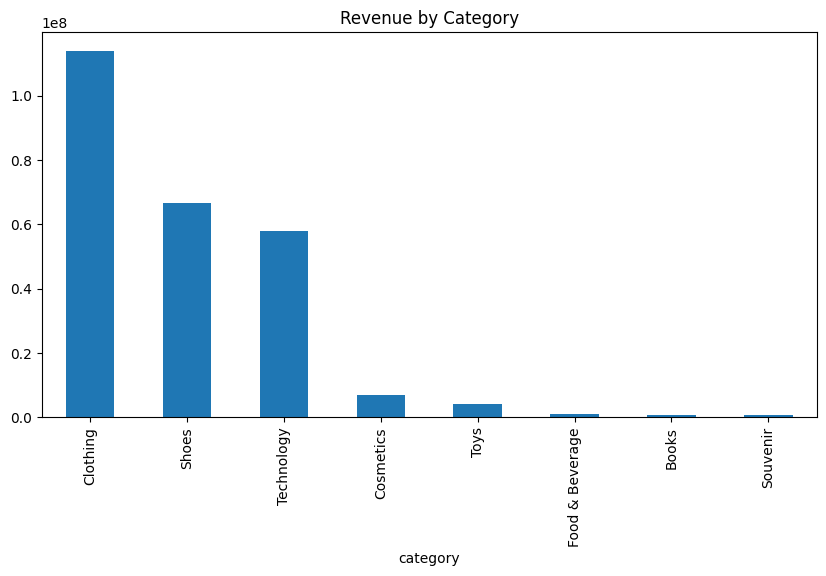

In [47]:
category_revenue = (df.groupby("category")["Revenue"].sum().sort_values(ascending=False))
category_revenue

plt.figure(figsize=(10,5))
category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.savefig("Revenue by Category.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
  Clothing generated the highest revenue among all categories.

### Why It Matters
  Customers appear to spend significantly more money on clothing products.

### My Recommendation
  The company should maintain strong inventory levels and focus promotional efforts on the Clothing category.

## Which gender contributes more revenue?

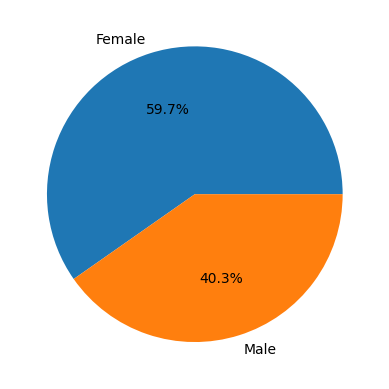

In [48]:
gender_revenue = ( df.groupby("gender")["Revenue"].sum())

gender_revenue
gender_revenue.plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")
plt.savefig("Gender Contribution.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
 Female customers generated more revenue than male customers.

### Why It Matters
 Female customers represent a valuable customer segment.

### My Recommendation
 The company can design targeted marketing campaigns aimed at female shoppers.

## Outlier Analysis
## Are there any unusually large transactions?

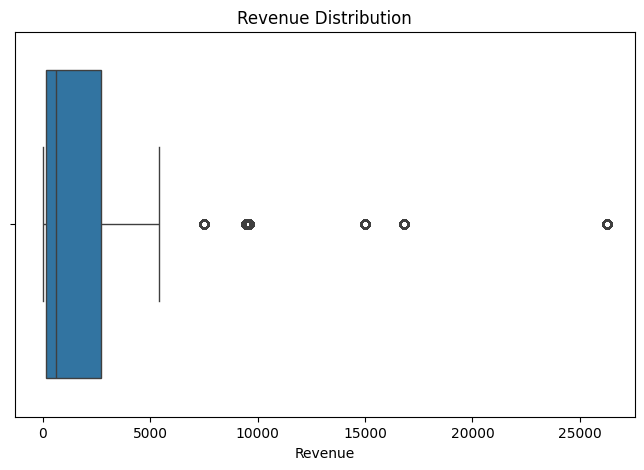

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Distribution")
plt.savefig("Revenue Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
The boxplot shows that most transactions are concentrated within a relatively small revenue range.
However, there are several points far beyond the upper whisker, indicating the presence of high-value transactions (outliers).
Some transactions generated revenue above 15,000–25,000, which is significantly higher than the majority of transactions.

### Why It Matters
Outliers can have a strong impact on average revenue and other statistical measures.
Identifying these transactions helps determine whether they represent genuine customer purchases or potential data quality issues.

### My Interpretation
The presence of high-value transactions is not necessarily a problem.
Given that the dataset includes categories such as Technology, these outliers likely represent customers purchasing expensive products or buying multiple items in a single transaction.

Since the business is retail-focused, these transactions can be considered valuable customers rather than errors in the data.

### My Recommendation
Retain these outliers because they likely represent legitimate business activity.
Analyze high-value transactions separately to understand which products and customer segments generate the most revenue.
Consider creating premium customer programs to retain high-spending customers.

## Age Group Analysis

In [49]:
bins = [18,25,35,45,55,65,100]
labels = [ "18-25", "26-35","36-45","46-55","56-65","65+"]

df["Age_Group"] = pd.cut(df["age"],bins=bins,labels=labels)

age_revenue = (df.groupby("Age_Group")["Revenue"].sum())
age_revenue

Age_Group
18-25    33720551.09
26-35    47879659.58
36-45    50184235.79
46-55    48219742.64
56-65    47893010.77
65+      19210874.12
Name: Revenue, dtype: float64

### What I Found
Customers aged 36-45 generated the highest revenue, contributing approximately 50.18 million in sales.
Revenue remains consistently high across the 26-35, 46-55, and 56-65 age groups, with each group contributing close to 48 million in revenue.
The 18-25 and 65+ age groups generated comparatively lower revenue, with the 65+ segment contributing the least.

### Why It Matters
The business is not dependent on a single age group. Revenue is distributed across several middle-aged customer segments.
Customers between 26 and 65 years old represent the most valuable customer base and account for the majority of total revenue.

### My Interpretation
Middle-aged customers generally have higher purchasing power and are likely more financially stable than younger customers.
The lower revenue from the 18-25 segment may be due to lower disposable income, while the 65+ segment may shop less frequently.

### My Recommendation
The company should focus its marketing efforts primarily on customers aged 26-65, as they contribute the largest share of revenue.
Special promotions and loyalty programs can be designed for these high-value age groups.
For the 18-25 segment, the company could introduce student discounts, budget-friendly offers, or targeted campaigns to increase engagement.

## Payment Method Analysis

In [50]:
payment_revenue = (df.groupby("payment_method")["Revenue"].sum().sort_values(ascending=False))
payment_revenue

payment_method
Cash           1.128322e+08
Credit Card    8.807712e+07
Debit Card     5.059643e+07
Name: Revenue, dtype: float64

### What I Found
Cash is the most preferred payment method, generating approximately 112.8 million in revenue. Credit Card transactions contributed around 88.1 million, while Debit Card transactions generated approximately 50.6 million in revenue.

### Why It Matters
Payment method preferences provide insights into customer purchasing behavior and transaction convenience. Understanding these preferences helps businesses optimize payment infrastructure and promotional strategies.

### My Interpretation
The significantly higher revenue generated through Cash payments suggests that a large portion of customers still prefer traditional payment methods. Credit Cards are the second most popular payment option, indicating strong adoption of digital payments, while Debit Cards contribute the least revenue among the three methods.

### My Recommendation
Ensure smooth and efficient cash handling processes since Cash accounts for the largest share of revenue.
Partner with banks and payment providers to offer discounts, cashback, or rewards on Credit Card and Debit Card transactions.
Encourage digital payment adoption to improve transaction speed, security, and customer convenience.

## Average revenue per transaction for each category

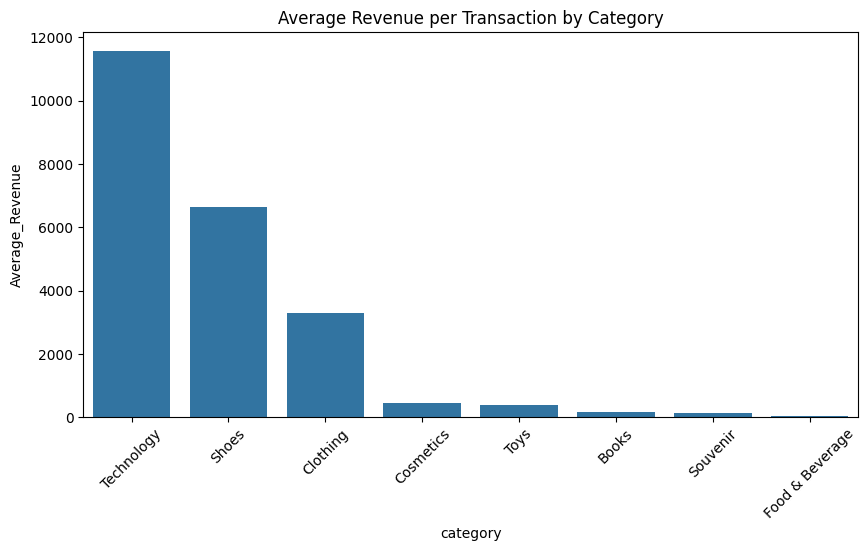

In [51]:
avg_revenue_category = (df.groupby("category").agg(Average_Revenue=("Revenue","mean"))
    .reset_index().sort_values(by="Average_Revenue",ascending=False))

avg_revenue_category

plt.figure(figsize=(10,5))
sns.barplot(
    data=avg_revenue_category,
    x="category",
    y="Average_Revenue")

plt.title("Average Revenue per Transaction by Category")
plt.xticks(rotation=45)
plt.savefig("Average Revenue per Transaction by Category.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
Technology has the highest average revenue per transaction, followed by Shoes and Clothing. Food & Beverage, Souvenir, and Books 
have the lowest average transaction values.

### Why It Matters
This tells us how much customers typically spend in a single purchase for each category.
Although Clothing may generate high total revenue, Technology products bring in much higher revenue per transaction because of their higher prices.

#### My Interpretation
Customers buy Technology products less frequently, but when they do purchase them, 
hey spend significantly more money per transaction compared to other categories.

#### My Recommendation
The company should:
Focus on upselling premium Technology products.
Create bundle offers for Shoes and Clothing categories.
Increase basket size in low-value categories such as Food & Beverage and Souvenirs through combo deals and cross-selling.

## Shopping Mall Analysis

In [64]:
mall_revenue = ( df.groupby("shopping_mall")["Revenue"].sum().sort_values(ascending=False))
mall_revenue.head(10)

shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Istanbul       12303921.24
Name: Revenue, dtype: float64

### What I Found
Mall of Istanbul generated the highest revenue, contributing approximately 50.87 million, closely followed by Kanyon with 50.55 million in revenue.
Metrocity ranked third with 37.30 million in revenue, while Metropol AVM and Istinye Park generated around 25 million each.
The lowest-performing malls were Forum Istanbul, Emaar Square Mall, Viaport Outlet, and Cevahir AVM, each contributing around 12–13 million in revenue.

### Why It Matters
Shopping mall performance directly impacts overall business revenue. Identifying high-performing and low-performing locations helps businesses allocate resources more effectively and understand location-based customer behavior.

### My Interpretation
Revenue is not distributed equally across shopping malls. Mall of Istanbul and Kanyon are the strongest revenue-generating locations, suggesting higher customer traffic, stronger purchasing power, better store mix, or more effective business operations.
On the other hand, several malls generate less than one-fourth of the revenue produced by the top-performing malls, indicating potential opportunities for improvement.

### My Recommendation
Study the success factors of Mall of Istanbul and Kanyon, such as customer traffic, product assortment, and promotional activities.
Replicate successful strategies in lower-performing malls where feasible.
Conduct further analysis to determine whether lower revenue is caused by fewer transactions, lower average spending, or reduced customer footfall.
Allocate marketing budgets and inventory more strategically based on mall performance.

## Creating a month column

In [67]:
df["invoice_date"] = pd.to_datetime(
    df["invoice_date"],
    format="%d/%m/%Y"
)
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["Month"] = df["invoice_date"].dt.month_name()

## Define a proper month column

In [68]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"]

df["Month"] = pd.Categorical(df["Month"],categories=month_order,ordered=True)

## Monthly revenue

In [69]:
monthly_revenue = (df.groupby("Month")["Revenue"].sum())
monthly_revenue

Month
January      28891525.59
February     26625090.10
March        21956191.33
April        18715685.98
May          19719331.10
June         18933775.30
July         20378722.63
August       19282361.29
September    18795794.91
October      20545090.43
November     18207139.95
December     19455085.64
Name: Revenue, dtype: float64

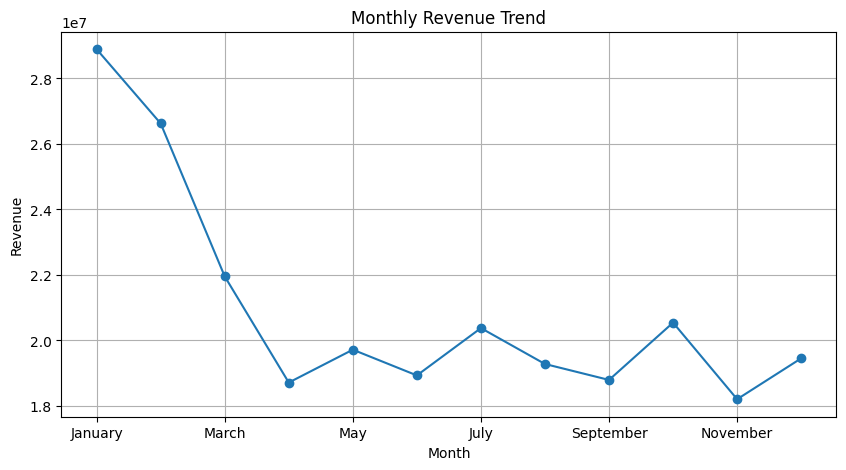

In [53]:
plt.figure(figsize=(10,5))

monthly_revenue.plot(kind="line",marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)
plt.savefig("Monthly Revenue Trend.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
Revenue was highest in January (approximately 28.9 million) and gradually declined until April.
After April, revenue remained relatively stable between 18–21 million, with small fluctuations throughout the year.
A slight increase can be observed in July and October, while November recorded the lowest revenue of the year.

### Why It Matters
Monthly revenue analysis helps identify seasonal trends and periods of strong or weak business performance.
Understanding these patterns enables businesses to plan inventory, staffing, and marketing activities more effectively.

### My Interpretation
The business experienced its strongest performance during the beginning of the year, particularly in January and February.
After the first quarter, revenue stabilized at a lower level, suggesting that customer demand may be influenced by seasonal factors, promotional periods, or holiday-related shopping behavior.

However, the dataset alone does not provide enough information to determine the exact reason for these fluctuations.

### My Recommendation
Investigate the factors contributing to strong sales in January and February.
Replicate successful promotions or campaigns during lower-performing months.
Increase marketing efforts before periods where revenue typically declines.
Conduct further analysis to identify whether specific product categories are driving seasonal changes in revenue.

## Category Preference by Gender
#### Do male and female customers prefer different product categories?

<Figure size 1000x500 with 0 Axes>

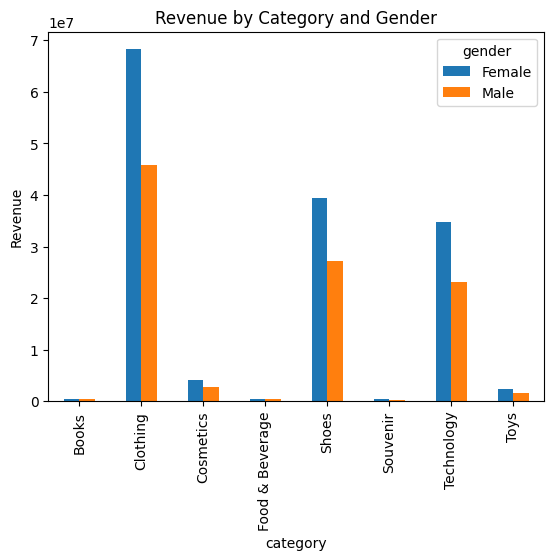

In [54]:
gender_category = pd.pivot_table(df,values="Revenue",index="category",columns="gender",aggfunc="sum")
gender_category

plt.figure(figsize=(10,5))
gender_category.plot(kind="bar")

plt.title("Revenue by Category and Gender")
plt.ylabel("Revenue")
plt.savefig("Revenue by Category and Gender.png", dpi=300, bbox_inches="tight")
plt.show()


### What I Found
Female customers generated higher revenue than male customers across all product categories.
The largest revenue contribution came from the Clothing category for both genders, with female customers contributing significantly more revenue than male customers.
Technology and Shoes were the second and third highest revenue-generating categories, and again, female customers outspent male customers in these categories.
Lower-revenue categories such as Books, Food & Beverage, and Souvenirs showed relatively small differences between male and female spending.

### Why It Matters
This analysis helps identify customer preferences and spending patterns across different demographic groups.
Understanding which customer segments contribute the most revenue can help businesses design more effective marketing campaigns and product strategies.

### My Interpretation
Female customers appear to be the primary revenue drivers in this dataset, particularly in high-revenue categories such as Clothing, Shoes, and Technology.
The consistent revenue gap across categories suggests that female customers either shop more frequently, purchase larger quantities, or spend more per transaction than male customers.

However, additional analysis would be required to determine the exact reason behind this difference.

### My Recommendation
Develop targeted marketing campaigns for female customers, especially in Clothing, Shoes, and Technology categories.
Investigate customer purchase frequency and average order value by gender to better understand spending behavior.
Create personalized promotions and loyalty programs for the highest-spending customer segments.
Explore opportunities to increase engagement and spending among male customers.

## Category Preference by Gender

### Business Question
### Do male and female customers prefer different product categories?

<Figure size 1000x500 with 0 Axes>

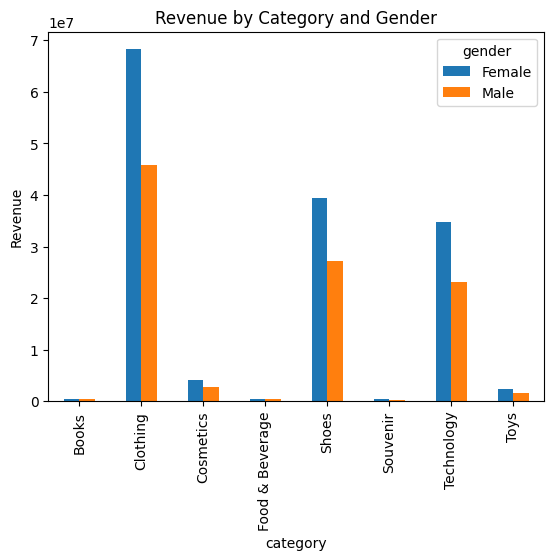

In [55]:
gender_category = pd.pivot_table(df,values="Revenue",index="category",columns="gender",aggfunc="sum")
gender_category


plt.figure(figsize=(10,5))
gender_category.plot(kind="bar")

plt.title("Revenue by Category and Gender")
plt.ylabel("Revenue")
plt.savefig("Revenue by Category and Gender 2.png", dpi=300, bbox_inches="tight")
plt.show()


### What I Found
Female customers generated higher revenue than male customers across all product categories.
For both genders, Clothing was the highest revenue-generating category, followed by Shoes and Technology.
The largest gender gap can be observed in the Clothing category, where female customers contributed substantially more revenue than male customers.
Lower-revenue categories such as Books, Food & Beverage, and Souvenirs contributed only a small portion of overall revenue for both genders.

### Why It Matters
This analysis helps identify which customer segments contribute the most revenue and whether product preferences differ by gender.
Understanding these patterns allows businesses to design targeted marketing campaigns and optimize product offerings.

### My Interpretation
Although male and female customers show similar category preferences, female customers consistently generate more revenue across every category.
This suggests that female customers may shop more frequently, purchase larger quantities, or spend more per transaction than male customers.
The strong performance of Clothing, Shoes, and Technology indicates that these categories are the primary revenue drivers regardless of gender.

### My Recommendation
Focus marketing campaigns on female customers, particularly in Clothing, Shoes, and Technology categories.
Introduce loyalty programs for high-spending customer segments.
Conduct further analysis on transaction frequency and average order value by gender to better understand spending behavior.
Continue investing in top-performing categories while exploring opportunities to increase engagement in lower-performing categories.

## Category Performance Across Age Groups

### Business Question
### Which product categories are most popular among different age groups?

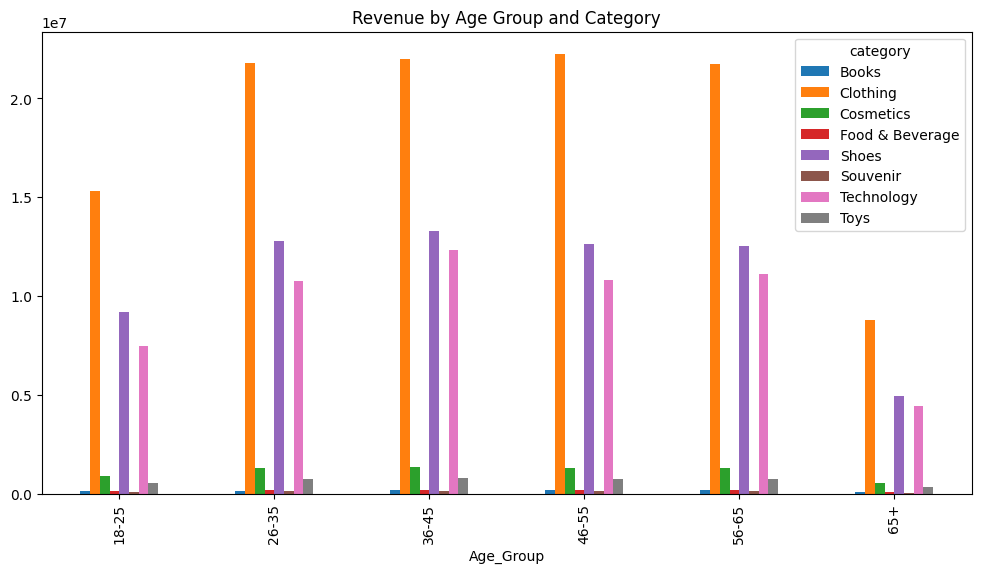

In [56]:
age_category = pd.pivot_table(df,values="Revenue",index="Age_Group",columns="category",aggfunc="sum")
age_category

age_category.plot(kind="bar",figsize=(12,6))

plt.title("Revenue by Age Group and Category")
plt.savefig("Revenue by Age Group and Category.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
Customers aged 36–45 generated the highest revenue across most product categories.
Clothing was the highest revenue-generating category in every age group, making it the strongest product category overall.
Shoes and Technology were the second and third highest revenue contributors across most age groups.
Revenue from customers aged 65+ was noticeably lower across all categories compared to other age groups.

### Why It Matters
This analysis helps understand how purchasing behavior varies across different age groups and product categories.
Identifying the most valuable customer segments allows businesses to focus their marketing and sales efforts more effectively.

### My Interpretation
The data suggests that customers between 26 and 65 years old are the primary revenue drivers for the business.
The strong performance of Clothing across all age groups indicates that it is a universally popular category rather than being dependent on a specific age segment.
The lower revenue from the 65+ age group may indicate lower shopping frequency or lower spending levels.

### My Recommendation
Continue investing in the Clothing category as it consistently performs well across all age groups.
Design targeted marketing campaigns for customers aged 26–65, as they contribute the majority of revenue.
Explore special offers and loyalty programs for the 65+ segment to increase engagement and spending.
Further analyze customer purchase frequency to understand why certain age groups contribute more revenue.

## Category Demand Analysis

### Business Question
### Which categories sell the highest number of units?

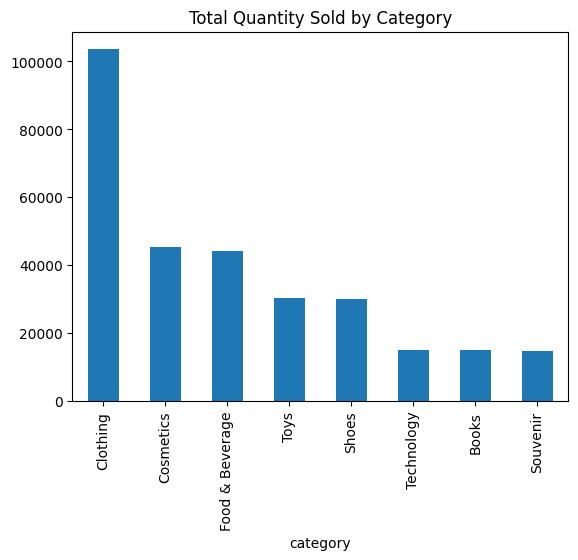

In [57]:
category_quantity = (df.groupby("category")["quantity"].sum().sort_values(ascending=False))
category_quantity

category_quantity.plot(kind="bar")

plt.title("Total Quantity Sold by Category")
plt.savefig("Total Quantity Soly By Category.png", dpi=300, bbox_inches="tight")
plt.show()


### What I Found
Clothing sold the highest number of units by a significant margin, with more than 100,000 units sold, making it the most demanded category in the dataset.
Cosmetics and Food & Beverage were the next most purchased categories, followed by Toys and Shoes.
Technology, Books, and Souvenirs recorded the lowest quantity sold among all categories.

### Why It Matters
Quantity sold helps measure customer demand, while revenue measures financial performance.
A category may generate high revenue because of higher prices, but quantity sold shows what customers actually buy most frequently.

### My Interpretation
Clothing is not only the highest revenue-generating category but also the most purchased category, indicating strong and consistent customer demand.
Interestingly, Technology has relatively low quantity sold but still generates high revenue in earlier analyses. This suggests that Technology products are more expensive and generate higher revenue per purchase.
This analysis highlights the difference between high-demand products and high-value products.

### My Recommendation
Continue maintaining strong inventory levels for Clothing products due to consistently high demand.
Focus on product availability and promotions in Cosmetics and Food & Beverage, as they also show strong customer demand.
For Technology products, focus on premium offerings and upselling strategies rather than increasing quantity sold.
Monitor low-demand categories such as Books and Souvenirs to identify opportunities for growth.

## Revenue Contribution Analysis

### Business Question
### How much does each category contribute to total revenue?

In [58]:
category_share = (df.groupby("category")["Revenue"].sum()/ df["Revenue"].sum()) * 100

category_share.sort_values(ascending=False)

category
Clothing           45.325712
Shoes              26.461995
Technology         23.006369
Cosmetics           2.700877
Toys                1.582638
Food & Beverage     0.337780
Books               0.331823
Souvenir            0.252807
Name: Revenue, dtype: float64

### What I Found
Clothing contributed the largest share of total revenue, accounting for approximately 45.3% of overall sales.
Shoes and Technology were the second and third largest contributors, generating around 26.5% and 23.0% of total revenue respectively.
Together, Clothing, Shoes, and Technology contributed more than 94% of total revenue, making them the primary revenue drivers for the business.
The remaining categories, including Cosmetics, Toys, Food & Beverage, Books, and Souvenirs, contributed only a small portion of overall revenue.

### Why It Matters
Revenue contribution analysis helps identify which product categories have the greatest impact on business performance.
Understanding revenue concentration allows businesses to prioritize resources, inventory management, and marketing investments more effectively.

### My Interpretation
The business relies heavily on a small number of categories, particularly Clothing, Shoes, and Technology.
While this concentration helps generate strong revenue, it may also create dependency on a limited set of product categories.
The low contribution from categories such as Books and Souvenirs suggests that they play a relatively minor role in overall business performance.

### My Recommendation
Continue investing in Clothing, Shoes, and Technology, as they are responsible for the majority of revenue.
Ensure adequate inventory and promotional support for these high-performing categories.
Explore opportunities to improve sales in lower-performing categories through targeted promotions and product bundling.
Monitor revenue concentration risk and diversify category performance where possible.

## Shopping Mall Performance Analysis

### Business Question
### Which shopping malls perform best in terms of revenue and transactions?

In [59]:
mall_summary = df.groupby("shopping_mall").agg(
    Total_Revenue=("Revenue","sum"),
    Transactions=("invoice_no","nunique"),
    Average_Revenue=("Revenue","mean"))

mall_summary.sort_values(
    by="Total_Revenue",
    ascending=False)

,Total_Revenue,Transactions,Average_Revenue
shopping_mall,,,
Mall of Istanbul,50872481.68,19943,2550.894132
Kanyon,50554231.10,19823,2550.281547
Metrocity,37302787.33,15011,2485.030133
Metropol AVM,25379913.19,10161,2497.777108
Istinye Park,24618827.68,9781,2517.005181
Zorlu Center,12901053.82,5075,2542.079570
Cevahir AVM,12645138.20,4991,2533.588099
Viaport Outlet,12521339.72,4914,2548.095181
Emaar Square Mall,12406100.29,4811,2578.694718


### What I Found
Mall of Istanbul generated the highest total revenue (50.87 million) and also recorded the highest number of transactions (19,943).
Kanyon performed almost identically, generating 50.55 million in revenue from 19,823 transactions.
Metrocity ranked third in terms of both revenue and transaction count, while Forum Istanbul generated the lowest revenue among all shopping malls in the dataset.
Interestingly, the Average Revenue per Transaction is very similar across all malls, ranging between approximately 2,485 and 2,579.

### Why It Matters
Looking at revenue alone does not tell the complete story. By analyzing revenue, transaction count, and average revenue together, we can better understand what drives mall performance.
This helps determine whether a mall performs well because customers spend more per purchase or simply because it attracts more customers.

### My Interpretation

One interesting finding is that the average revenue per transaction remains relatively consistent across all shopping malls.
This suggests that the main reason some malls generate more revenue is higher customer traffic and transaction volume, not necessarily higher spending per customer.
For example, Mall of Istanbul and Kanyon outperform other malls mainly because they process significantly more transactions rather than having a much higher average transaction value.

### My Recommendation
Focus marketing and expansion efforts on high-traffic malls such as Mall of Istanbul and Kanyon.
Study what drives customer traffic in top-performing malls and apply similar strategies to lower-performing locations.
Since spending per transaction is relatively consistent across malls, increasing customer footfall may have a greater impact on revenue than trying to increase transaction value.
Consider local promotions and events in lower-performing malls to attract more customers.

## Customer Segmentation

### Business Question
### Can customers be grouped based on their spending behavior?

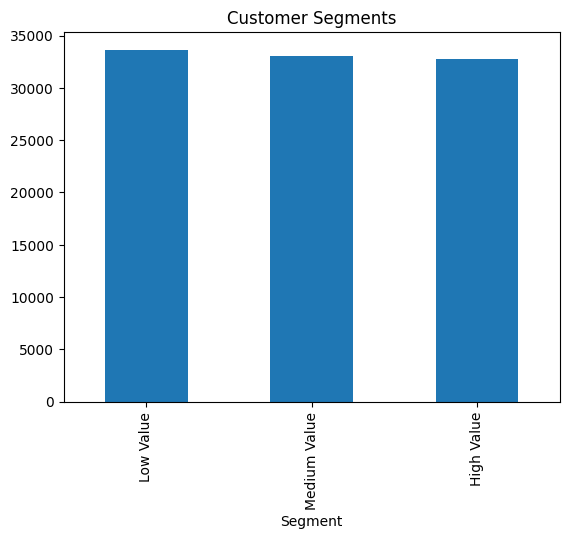

In [60]:
customer_revenue = (df.groupby("customer_id")["Revenue"].sum().reset_index())

customer_revenue["Segment"] = pd.qcut(customer_revenue["Revenue"],q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"])

customer_revenue["Segment"].value_counts()
customer_revenue["Segment"].value_counts().plot( kind="bar")

plt.title("Customer Segments")
plt.savefig("Customer Segments.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
The customer base is distributed quite evenly across all three segments: Low Value, Medium Value, and High Value customers.
No single segment dominates the customer population, as each segment contains approximately 33,000 customers.
This indicates that customers are fairly balanced across spending levels.

### Why It Matters
Customer segmentation helps businesses understand the composition of their customer base and develop targeted marketing strategies.
A balanced distribution reduces the risk of relying too heavily on a single customer segment.

### My Interpretation
One interesting observation is that the business serves customers from all spending levels rather than depending mainly on high-spending customers.
This suggests a diverse customer base, which is generally a positive sign because revenue is likely coming from multiple customer groups.

However, simply counting customers does not tell us which segment generates the most revenue. Further analysis should compare revenue generated by each segment.

### My Recommendation
Develop different marketing strategies for each customer segment.
Focus on retaining High Value customers through loyalty programs and exclusive offers.
Encourage Medium Value customers to increase spending through personalized promotions.
Design engagement campaigns for Low Value customers to improve customer lifetime value.

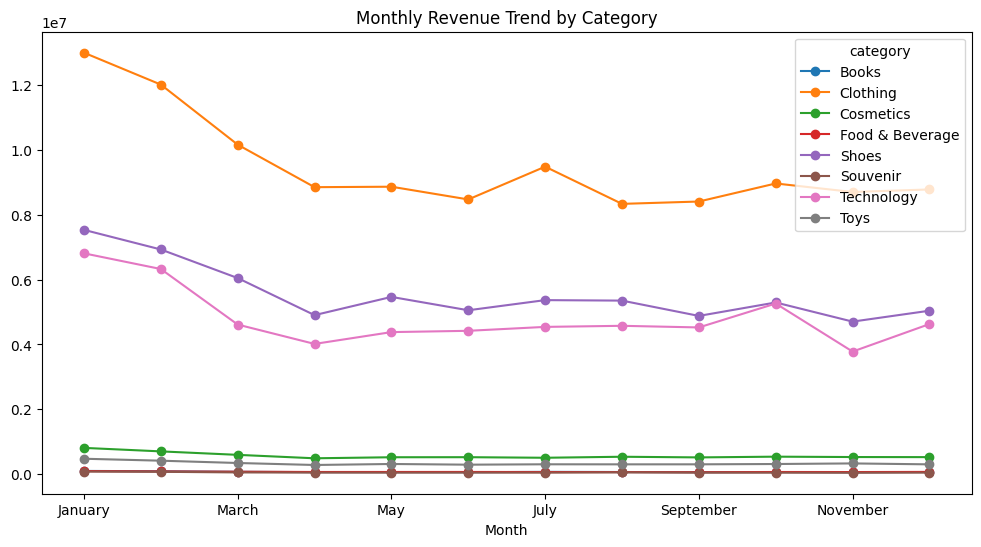

In [70]:
monthly_category = pd.pivot_table( df, values="Revenue", index="Month",
                                   columns="category", aggfunc="sum")

monthly_category
monthly_category.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Monthly Revenue Trend by Category")
plt.savefig("Monthly Revenue Trend by Category.png", dpi=300, bbox_inches="tight")
plt.show()


### What I Found
Clothing remained the highest revenue-generating category throughout the year, consistently outperforming all other product categories.
Shoes and Technology were the second and third strongest categories and showed relatively stable revenue across most months.
Most categories experienced a decline in revenue after the beginning of the year, with January and February generally showing stronger sales performance.

Lower-revenue categories such as Books, Food & Beverage, Souvenirs, and Toys remained fairly stable throughout the year with only minor fluctuations.

### Why It Matters
Analyzing monthly category performance helps identify which product categories drive revenue consistently and whether any category is affected by seasonal changes.
This information can support inventory planning, marketing campaigns, and business forecasting.

### My Interpretation
One interesting observation is that the ranking of categories remains almost unchanged throughout the year.
Clothing consistently leads revenue generation, while Shoes and Technology continue to be strong performers across all months.

This suggests that customer demand for these categories is stable rather than dependent on a specific season or promotional period.
Although revenue fluctuates slightly month-to-month, there is no dramatic shift in category performance.

### My Recommendation
Continue prioritizing Clothing, Shoes, and Technology as they are the primary revenue drivers.
Maintain sufficient inventory for these categories throughout the year.
Investigate opportunities to increase sales in lower-performing categories through targeted promotions and product bundling.
Conduct additional analysis using multiple years of data to determine whether any seasonal patterns exist.

## Correlation Analysis
### Which factors have the strongest relationship with revenue?

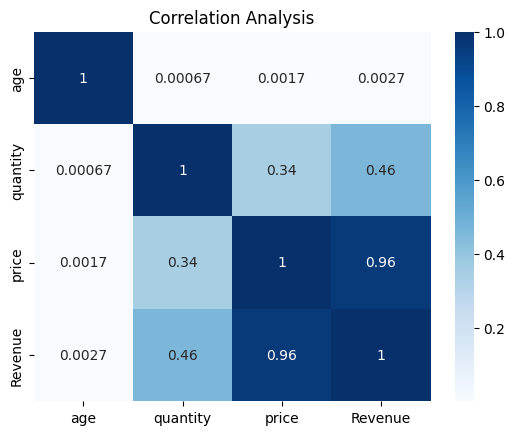

In [76]:
numeric_cols = ["age","quantity","price","Revenue"]
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="Blues")
plt.title('Correlation Analysis')
plt.savefig("Correlation Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### What I Found
The strongest relationship in the dataset is between Price and Revenue, with a correlation of 0.96.
Quantity also shows a positive relationship with Revenue (0.46), although the impact is much weaker compared to Price.
Age has almost no correlation with Revenue (0.0027), indicating that customer age does not significantly influence transaction value.
Additionally, Quantity and Price have a moderate positive correlation (0.34).

### Why It Matters
Correlation analysis helps identify which variables have the greatest influence on revenue generation.
Understanding these relationships allows businesses to focus on the factors that drive sales growth.

### My Interpretation
One of the most interesting findings is that Price is a much stronger driver of revenue than Quantity.
This suggests that revenue growth is largely influenced by the sale of higher-priced products rather than simply selling more units.
The almost zero correlation between Age and Revenue indicates that customers from different age groups spend similar amounts on average.

Therefore, product pricing and product mix appear to have a much greater impact on revenue than customer demographics.

### My Recommendation
Focus on promoting high-value product categories such as Technology, Shoes, and Clothing.
Increase average order value through premium products and upselling strategies.
Use customer age for segmentation and marketing purposes rather than revenue prediction.
Continue monitoring product pricing strategies because price has the strongest relationship with revenue.

## Top Customers by Revenue

In [75]:
top_customers = (df.groupby("customer_id")["Revenue"].sum().sort_values(ascending=False)
    .head(10))

top_customers

customer_id
C255975    26250.0
C219246    26250.0
C471560    26250.0
C477683    26250.0
C476770    26250.0
C100322    26250.0
C176113    26250.0
C276116    26250.0
C472297    26250.0
C162292    26250.0
Name: Revenue, dtype: float64

### What I Found
The top 10 customers each generated 26,250 in total revenue.
Interestingly, all top customers have exactly the same revenue value, indicating a tie among the highest-spending customers.
No single customer stands out as the clear highest spender.

### Why It Matters
Identifying top customers helps businesses understand who contributes the most revenue and supports customer retention strategies.
High-value customers often represent an important source of repeat business and long-term revenue.

### My Interpretation
The fact that multiple customers generated the same maximum revenue suggests that the business does not rely heavily on a single customer.
This is a positive sign because revenue appears to be distributed across multiple high-value customers rather than concentrated in one individual.
It may also indicate that there is a limit on transaction size or that several customers purchased similar high-value products.

### My Recommendation
Create loyalty programs for top-spending customers to encourage repeat purchases.
Analyze the purchase history of these customers to understand which products generate the highest customer value.
Use personalized offers and promotions to improve customer retention.
Investigate whether these customers share similar purchasing patterns or category preferences.

# Executive Summary

This analysis examined customer shopping behavior across product categories, customer demographics, payment methods, shopping malls, and time periods to identify key revenue drivers and business opportunities.

### Key Findings
The dataset contains approximately 99,457 transactions with no missing values, indicating a clean and reliable dataset for analysis.
Clothing is the strongest-performing category, contributing approximately 45.3% of total revenue, making it the primary revenue driver.
Shoes (26.5%) and Technology (23.0%) are the second and third largest revenue contributors, together accounting for a significant share of total      sales.
Customers aged 26–65 years generate the majority of revenue, with the 36–45 age group contributing the highest sales.
Cash payments generate the highest revenue, followed by Credit Card and Debit Card transactions.
Mall of Istanbul and Kanyon are the top-performing shopping malls, each generating over 50 million in revenue.
Revenue peaks during the early months of the year and remains relatively stable throughout the remaining months.
Female customers generate higher revenue than male customers across most product categories, particularly in Clothing, Shoes, and Technology.
Correlation analysis shows that Price has a very strong relationship with Revenue (0.96), while Age has almost no impact on Revenue, indicating that spending is driven more by product value than customer age.
Customer segmentation reveals a balanced distribution of customers across spending levels, suggesting a diverse customer base rather than dependence on a small group of buyers.

### Business Recommendations
Continue prioritizing the Clothing category, as it is the largest contributor to revenue.
Strengthen marketing campaigns targeting customers aged 26–65, who represent the most valuable customer segment.
Focus promotional efforts on top-performing malls such as Mall of Istanbul and Kanyon.
Encourage higher-value purchases through premium product offerings, as revenue is strongly influenced by product price.
Develop loyalty programs for high-value customers to improve retention and increase lifetime customer value.
Investigate opportunities to improve sales in lower-performing categories such as Books, Souvenirs, and Food & Beverage.

### Conclusion
The analysis indicates that revenue is primarily driven by Clothing, Shoes, and Technology products, supported by middle-aged customers and strong performance from a few major shopping malls. The business benefits from a diversified customer base and stable revenue patterns, providing opportunities for targeted marketing, customer retention strategies, and category-focused growth initiatives.